In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [2]:
df = pd.read_csv("sales.csv")
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

In [3]:
df.head()

,sales
date,
2022-01-01,1200
2022-01-02,980
2022-01-03,1100
2022-01-04,870
2022-01-05,760


In [4]:
train = df.iloc[:-14]
test = df.iloc[-14:]
h = len(test)

# Check Stationarity

In [6]:
# Runs the ADF test on the raw training series
adf_raw = adfuller(train["sales"], autolag="AIC")
# p-value
print(f"Raw series ADF p-value: {adf_raw[1]:.4f}")
# ADF test statistic
print(f"ADF test statistic value: {adf_raw[0]:.4f}")

Raw series ADF p-value: 0.9935
ADF test statistic value: 0.9331


In [8]:
# subtracts each value from the one before it. Converts the series from levels to day-to-day changes.... Removes the trend.
sales_diff = train["sales"].diff().dropna()

# The first row becomes NaN after differencing (no previous value to subtract from). This removes that NaN row before passing to the ADF test — the test cannot handle NaN values.
adf_diff = adfuller(sales_diff, autolag="AIC")

# p-value of the ADF test on the differenced series. Should now be below 0.05 — confirming stationarity after differencing.
print(f"Differenced ADF p-value: {adf_diff[1]:.4f}")


# What this block does as a whole: Confirms the series needs differencing, applies it, and verifies the fix worked. This is mandatory before AR modelling.

Differenced ADF p-value: 0.0000


# Plot PACF to indentify Order p

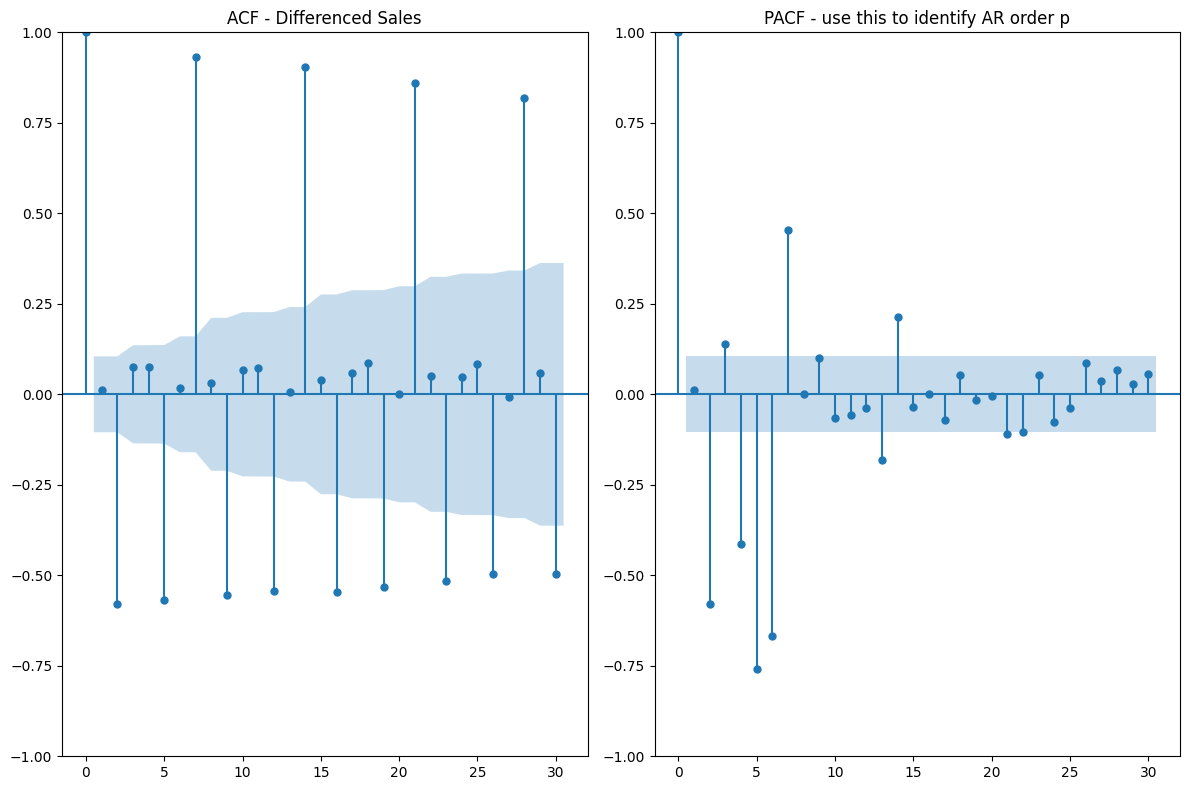

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# plots the ACF of the differenced series up to lag 30.
plot_acf(sales_diff, lags=30, ax = axes[0], title="ACF - Differenced Sales")

# plots the PACF of the differenced series.
# method='ywm' — Yule-Walker with bias correction. This is the most numerically stable PACF estimation method and the safest default for real-world data. The alternative method='ols' uses OLS regression and is more accurate for very small samples but slower
plot_pacf(sales_diff, lags = 30, method="ywm", ax = axes[1], title="PACF - use this to identify AR order p")

plt.tight_layout()
plt.show()


# What you are looking for in the PACF plot: The lag where the bars drop inside the shaded confidence band and stay there. That lag number is your p. For the sales data, expect to see significant spikes at lag 1 (daily momentum) and lag 7 (weekly pattern). Everything beyond lag 7 should be inside the band.